# 스케치 변환 미리보기

utils.py의 `convert_to_sketch_query()`와 동일한 파라미터:
- GaussianBlur(5, 5, sigma=1.0)
- Canny(30, 120)
- dilate(2×2, 1회)
- 흰 배경 + 검은 윤곽선

In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [14]:
def convert_to_sketch(image: Image.Image) -> Image.Image:
    """utils.py의 convert_to_sketch_query()와 동일한 로직"""
    img_array = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    blurred   = cv2.GaussianBlur(img_array, (5, 5), 1.0)
    edges     = cv2.Canny(blurred, 80, 200)
    edges     = cv2.dilate(edges, np.ones((2, 2), np.uint8), iterations=1)
    sketch    = 255 - edges                        # 흰 배경, 검은 선
    sketch_rgb = cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(sketch_rgb)

C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\1466273844.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLA

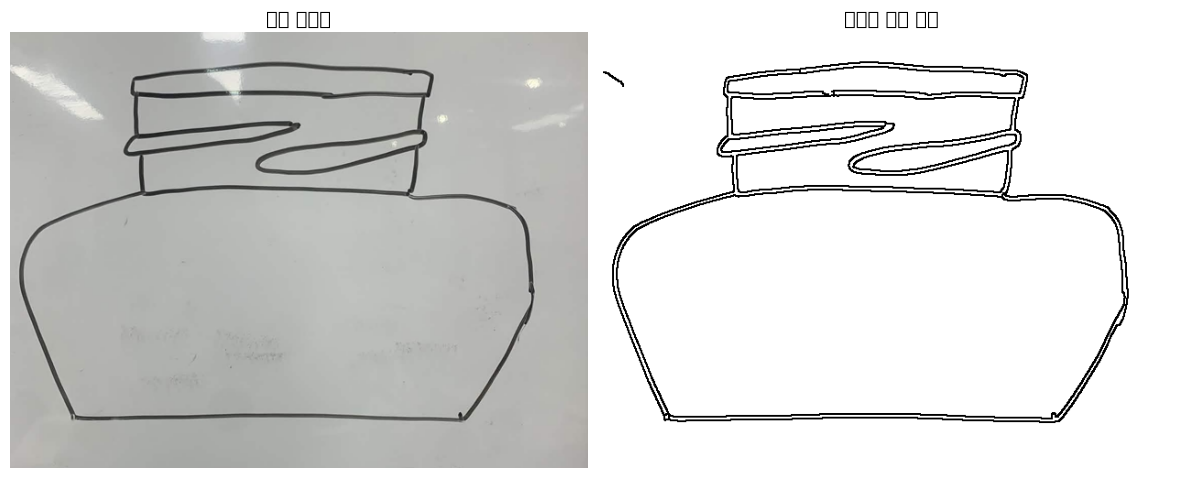

In [21]:
# 이미지 경로 입력
IMAGE_PATH = r"C:\Users\playdata2\Desktop\query_image_4.png"   # ← 여기에 이미지 경로 입력

original = Image.open(IMAGE_PATH).convert('RGB')
sketch   = convert_to_sketch(original)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original)
axes[0].set_title('원본 이미지', fontsize=14)
axes[0].axis('off')
axes[1].imshow(sketch)
axes[1].set_title('스케치 변환 결과', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\playdata2\AppData\Local\Temp\ipykernel_22388\162256283.py:22: UserWarning: Glyph 44368 (\N{HANGUL SYLLABL

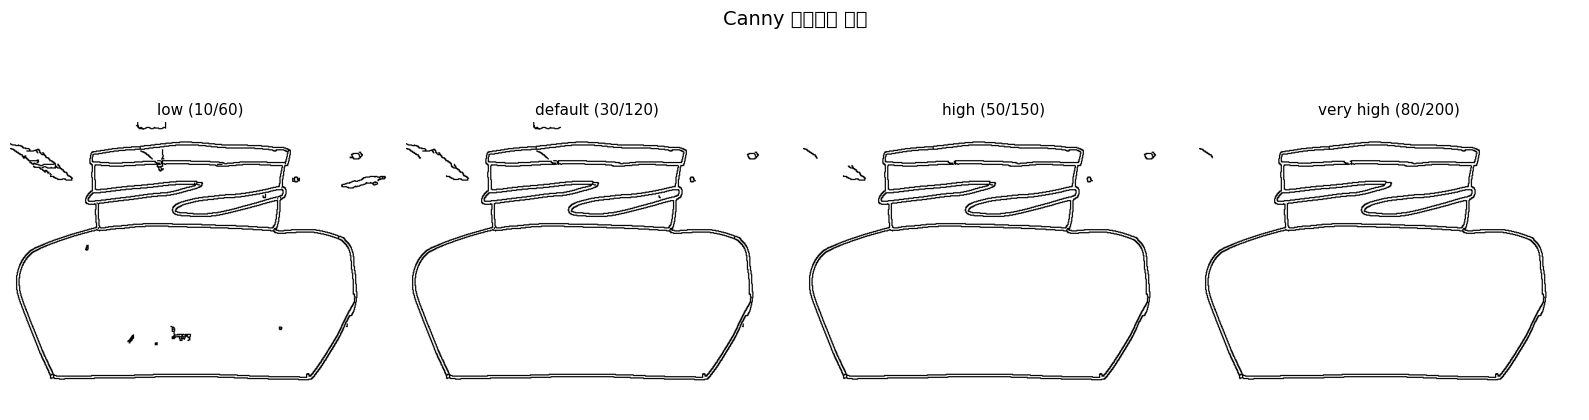

In [12]:
# Canny 임계값 비교 (파라미터 튜닝용)
configs = [
    (10,  60,  "low (10/60)"),
    (30, 120,  "default (30/120)"),   # 현재 설정
    (50, 150,  "high (50/150)"),
    (80, 200,  "very high (80/200)"),
]

img_gray = cv2.cvtColor(np.array(original), cv2.COLOR_RGB2GRAY)
blurred  = cv2.GaussianBlur(img_gray, (5, 5), 1.0)

fig, axes = plt.subplots(1, len(configs), figsize=(16, 5))
for ax, (lo, hi, label) in zip(axes, configs):
    edges  = cv2.Canny(blurred, lo, hi)
    edges  = cv2.dilate(edges, np.ones((2, 2), np.uint8), iterations=1)
    sketch = 255 - edges
    ax.imshow(sketch, cmap='gray')
    ax.set_title(label, fontsize=11)
    ax.axis('off')

plt.suptitle('Canny 임계값별 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 스케치 이미지 저장
OUTPUT_PATH = "sketch_output.jpg"
sketch.save(OUTPUT_PATH)
print(f"저장 완료: {OUTPUT_PATH}")